# Atelier Seaborn

## Contexte 
Une entreprise possède plusieurs bâtiments équipés de capteurs IoT. 
Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression, 
la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure. 
Après avoir utilisé NumPy pour manipuler les données numériques, Pandas pour importer, nettoyer 
et analyser le dataset et Matplotlib pour réaliser des visualisations, l'étape suivante consiste à se 
servir de Seaborn pour réaliser une analyse exploratoire plus riche des données. 

## Structure du projet 

### 1) Structurer le projet comme suit : 
atelier_seaborn_iot/ 
│ 
├── data/ 
│   
└── mesures_capteurs.csv 
│    
├── notebooks/ 
│   
└── atelier_seaborn_iot.ipynb
│ 
└── exports/ 
├── temperature.png 
├── temperature.pdf  
└── ... 

### 2) Stocker le fichier fourni mesures_capteurs.csv dans le sous-dossier data 
### 3) Créer le notebook atelier_seaborn_iot.ipynb 

In [17]:
%pip install ipykernel

Note: you may need to restart the kernel to use updated packages.


In [18]:
# Creation du fichier notebook dans le dossier notebooks
# %mkdir atelier_seaborn_iot.ipynb

### 4) Installer et importer seaborn, matplotlib, pandas, numpy 

In [19]:
# Installation (si besoin, décommenter)
# !pip install pandas numpy matplotlib seaborn

#%pip install numpy pandas matplotlib seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", rc={"figure.figsize": (10, 6)})
%matplotlib inline

**style="whitegrid"** définit l'apparence (fond blanc, grille légère, couleurs par défaut, etc.).

**rc** (pour "runtime configuration") permet de passer des réglages supplémentaires à matplotlib via seaborn. "figure.figsize": (10, 6) fixe la taille par défaut de chaque figure à 10 (largeur) sur 6 (hauteur), en pouces.

### 5) Importer mesures_capteurs.csv dans le dataframe df 

**Pour importer le fichier csv dans le dataframe df il faut:**
Charge le CSV dans un DataFrame pandas (tableau exploitable). Le ../ remonte d'un dossier depuis notebooks/ pour aller chercher data/.

In [20]:
df = pd.read_csv("../data/mesures_capteurs.csv")
#df.head() affiche les 5 premières lignes, pour vérifier que l'import est correct.
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


### 6) Vérifier le contenu du dataframe df 

In [21]:
#df.info() Structure du tableau : colonnes, types, valeurs non-nulles par colonne.
df.info()
print("_________________________________________________________________________________")
#df.isna().sum() Nombre de valeurs manquantes par colonne.
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB
_________________________________________________________________________________


id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     6
humidite        5
pression        5
consommation    5
etat            4
dtype: int64

In [22]:
#df.describe() Statistiques des colonnes numériques : moyenne, min, max, quartiles.
df.describe()

,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


## Partie 1 – Distribution d'une variable avec histplot()

**Objectif :** Visualiser comment les valeurs de température se répartissent : autour de quelle valeur elles sont concentrées, si la distribution est symétrique, et s'il y a des valeurs extrêmes.

### 1) Afficher la distribution des températures

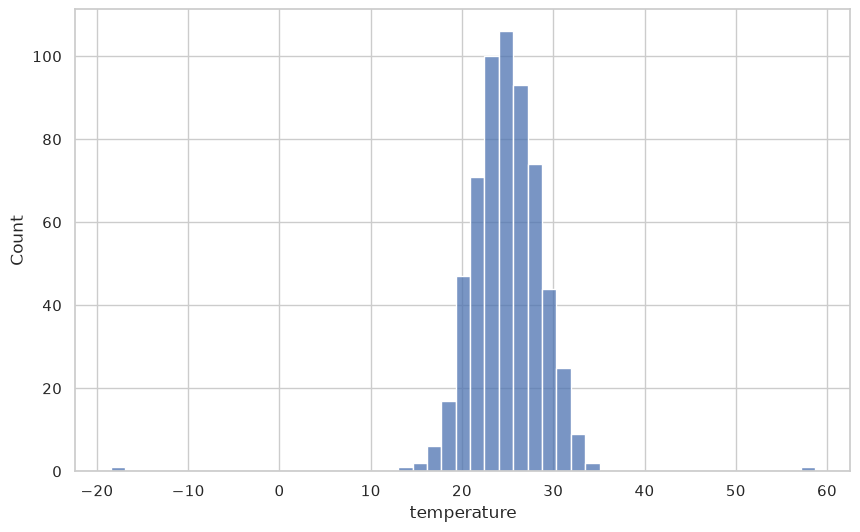

In [23]:
sns.histplot(data=df, x="temperature")
plt.show()

**data=df :** le DataFrame source

**x="temperature" :** la colonne à analyser

Seaborn découpe automatiquement les valeurs en "classes" (bins) et affiche une barre par classe, dont la hauteur correspond au nombre de mesures dans cette classe

### 2) Autour de quelle valeur les températures sont concentrées ?

In [24]:
print(df["temperature"].mean())
print(df["temperature"].median())

24.87831385642738
24.86


Les températures se concentrent principalement entre 20 et 30 °C, avec une moyenne de 24,88 °C et une médiane de 24,86 °C. 

Ces deux valeurs étant très proches, cela confirme que le pic de la distribution se situe bien autour de 25 °C.

###  3) La distribution semble-t-elle symétrique ? 

La distribution semble légèrement asymétrique : la majorité des températures sont concentrées autour de 25 °C, mais on observe quelques valeurs très faibles qui s'écartent nettement de ce groupe principal, avec très peu d'observations dans cette zone. 

Cela crée une traîne (queue) vers la gauche , ce qui rend la distribution non parfaitement symétrique.

In [25]:
df["temperature"].skew()

np.float64(-1.0470722374889554)

Le résultat est négatif, ça confirme une asymétrie vers la gauche comme on l'as observé.

### 4) Existe-t-il des valeurs extrêmes ? 

In [26]:
Q1 = df["temperature"].quantile(0.25)
Q3 = df["temperature"].quantile(0.75)
IQR = Q3 - Q1

borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

outliers = df[(df["temperature"] < borne_basse) | (df["temperature"] > borne_haute)]
print(f"Bornes : [{borne_basse:.2f}, {borne_haute:.2f}]")
print(f"Nombre de valeurs extrêmes : {len(outliers)}")
outliers

Bornes : [15.51, 34.33]
Nombre de valeurs extrêmes : 5


,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
43,M0575,2026-01-28 22:00:00,C011,B004,34.72,57.50,1008.94,266.22,ALERTE
245,M0127,2026-01-10 06:00:00,C007,B003,14.11,145.00,1032.36,169.57,ERREUR
258,M0223,2026-01-14 06:00:00,C007,B003,15.49,47.96,1006.34,124.90,OK
487,M0538,2026-01-27 09:00:00,C010,B004,-18.50,66.27,1012.49,312.92,ERREUR
502,M0048,2026-01-06 23:00:00,C012,B004,58.70,81.51,1026.79,271.92,ERREUR


**Sur les 5 valeurs extrêmes détectées :**

4 sur 5 sont associées à un état anormal du capteur (ALERTE ou ERREUR), ce qui suggère que ces températures extrêmes ne sont pas de simples variations naturelles, mais plutôt des dysfonctionnements de capteurs.

On trouve à la fois des valeurs anormalement basses (-18,50 °C, 14,11 °C) et anormalement hautes (58,70 °C, 34,72 °C) — ce qui explique pourquoi la distribution a une traîne des deux côtés, mais surtout vers la gauche comme vu avec le skewness.

Ces valeurs se concentrent surtout sur les bâtiments B003 et B004, notamment via les capteurs C007, C010, C011, C012.

Un seul outlier (15,49 °C) est marqué OK, ce qui suggère qu'il s'agit peut-être d'une vraie mesure basse plutôt que d'une anomalie technique.

### 5) Modifier le nombre de classes 

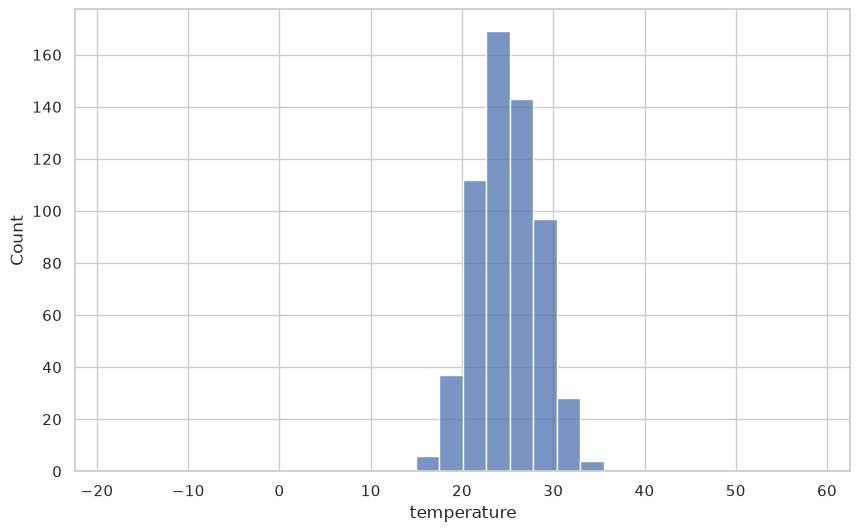

In [27]:
sns.histplot(data=df, x="temperature", bins=30)
plt.show()

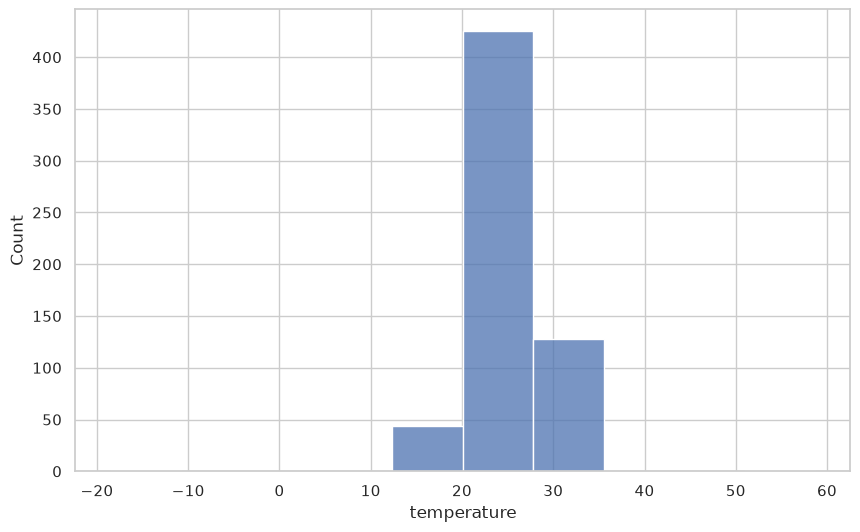

In [28]:
sns.histplot(data=df, x="temperature", bins=10)
plt.show()

Avec 10 bins, l'histogramme est très lissé : on ne distingue plus que 3 grandes barres, ce qui masque les détails de la distribution (les valeurs extrêmes en particulier disparaissent visuellement, noyées dans les classes larges).

Avec 30 bins, on obtient 8 barres visibles, ce qui donne plus de détail sur la forme de la distribution — mais les petites barres correspondant aux valeurs extrêmes (visibles dans l'histogramme par défaut) ne sont plus visibles non plus.

### 6) Afficher la distribution des températures par bâtiment

**hue** sert à découper les données par catégorie en utilisant une couleur différente pour chaque groupe.

**multiple="stack"** Ce paramètre contrôle comment les 4 distributions sont affichées les unes par rapport aux autres, une fois qu'on a déjà utilisé hue.

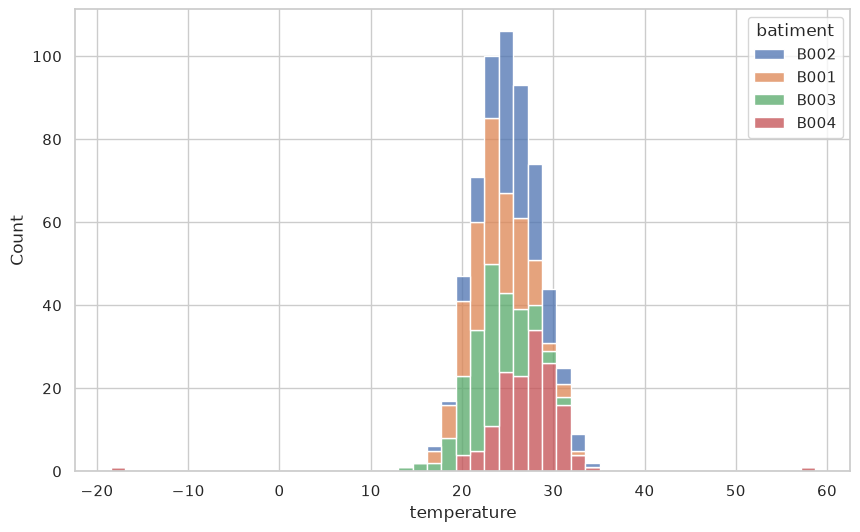

In [29]:
sns.histplot(data=df, x="temperature", hue="batiment", multiple="stack")
plt.show()

## Partie 2 – Distribution d'une variable avec kdeplot() 

### 1) Afficher la distribution des températures 

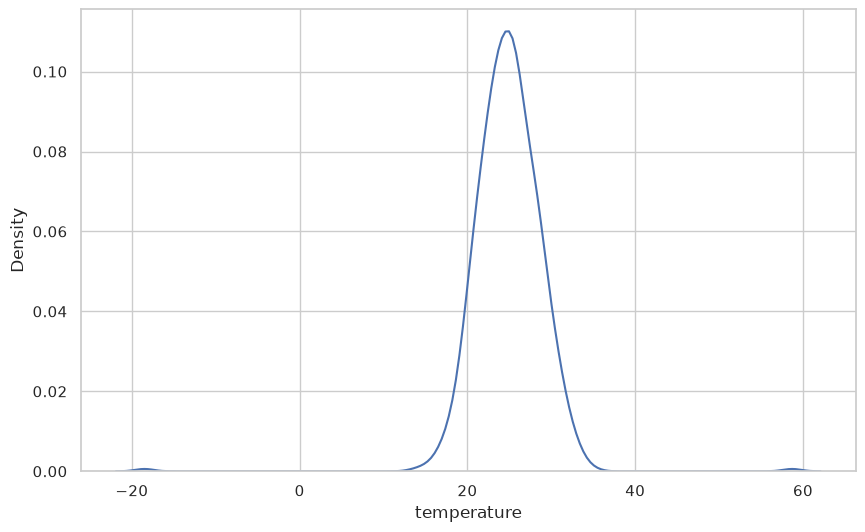

In [30]:
sns.kdeplot(data=df, x="temperature")
plt.show()

**Objectif:** Comme **histplot(), kdeplot()** montre la distribution d'une variable — mais au lieu de barres, il trace une courbe lissée qui estime la densité de probabilité. 

C'est utile pour voir la forme générale de la distribution sans dépendre du choix de bins.

**kdeplot** calcule une estimation de densité **(KDE = Kernel Density Estimation)** : au lieu de compter les valeurs par tranche comme l'histogramme, il "lisse" chaque point de donnée pour obtenir une courbe continue. 

Le résultat ressemble à un histogramme dont on aurait arrondi les contours, plus facile pour juger la forme générale (symétrie, nombre de pics) sans le bruit lié au choix des bins.

### 2) Afficher la distribution des températures par bâtiment

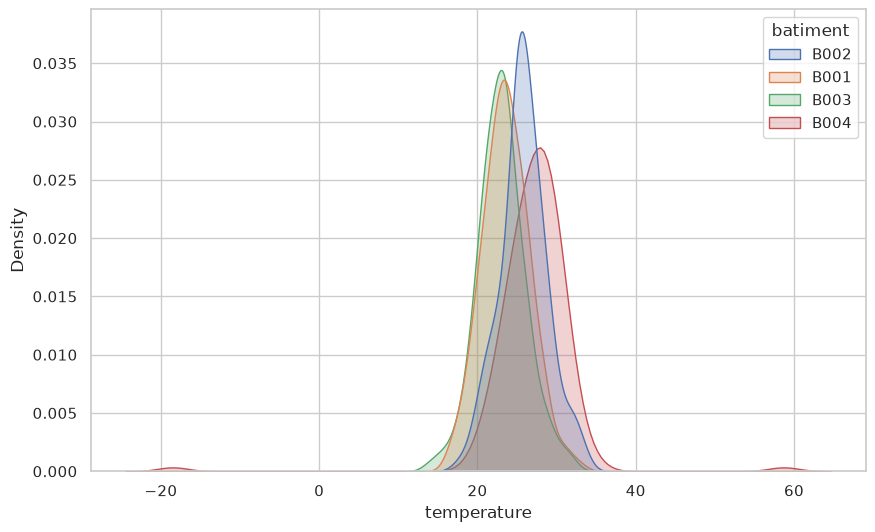

In [32]:
sns.kdeplot(data=df, x="temperature", hue="batiment", fill="True")
plt.show()

**Explication :** Même logique que pour histplot() — hue="batiment" trace une courbe par bâtiment, chacune dans sa couleur, ce qui permet de comparer directement la forme et la position des distributions entre bâtiments.

**Sans fill=True :** seaborn trace uniquement le contour de la courbe (une ligne), une couleur par bâtiment, sans remplissage.

**Avec fill=True :** seaborn remplit l'espace sous la courbe avec la couleur, et applique automatiquement une transparence (un peu comme alpha=0.5 effectivement) pour que les zones où plusieurs courbes se chevauchent restent lisibles — sinon une couleur opaque cacherait complètement les autres en dessous.

## Partie 3 – Distribution d'une variable avec boxplot() 

### 1) Afficher la distribution des températures 

**Objectif :** Le boxplot ("boîte à moustaches") résume une distribution avec quelques repères statistiques clés : médiane, quartiles, dispersion, valeurs extrêmes. Contrairement à histplot() et kdeplot(), il ne montre pas la forme détaillée de la distribution, mais donne une lecture rapide et standardisée de sa structure.

**Comment lire un boxplot :**

La boîte va du 1er quartile (Q1, 25%) au 3e quartile (Q3, 75%) → elle contient 50% des données

La ligne au milieu de la boîte = la médiane

Les moustaches (traits qui dépassent de la boîte) s'étendent jusqu'aux valeurs les plus extrêmes qui restent dans la plage [Q1 - 1,5×IQR, Q3 + 1,5×IQR]

Les points isolés au-delà des moustaches = les valeurs extrêmes (outliers)

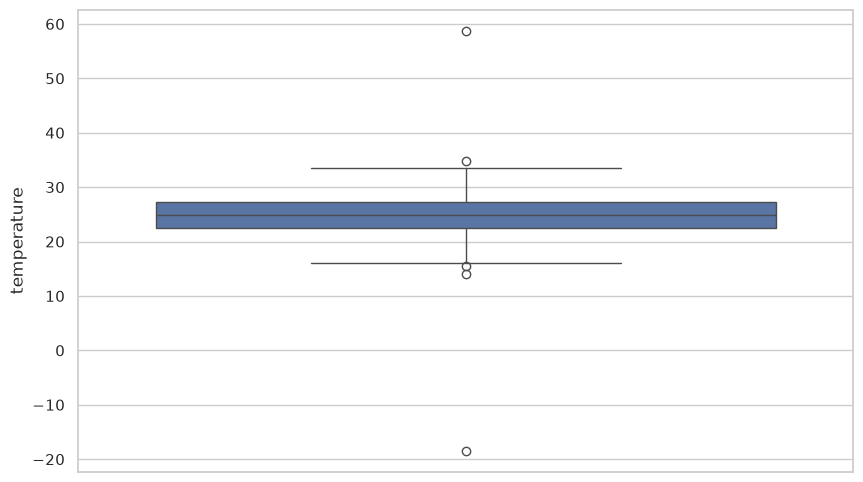

In [40]:
sns.boxplot(data=df, y="temperature")
plt.show()

**Explication :** y="temperature" (plutôt que x) trace la boîte verticalement, ce qui est la convention la plus lisible pour un seul boxplot.

### 2) Afficher la distribution des températures par bâtiment 

**Objectif :** Comparer visuellement la distribution des températures entre les 4 bâtiments, en utilisant un boxplot par bâtiment placé côte à côte.

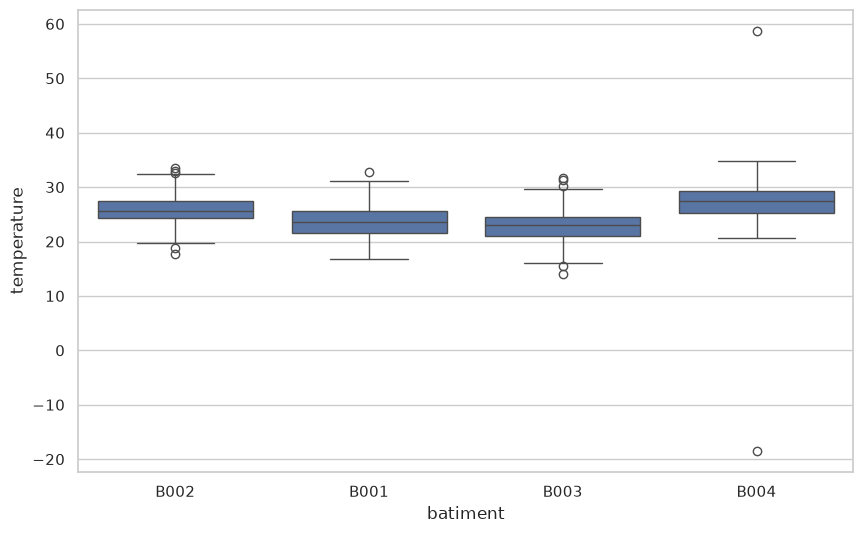

In [42]:
sns.boxplot(data=df, x="batiment", y="temperature")
plt.show()

**Ce que ça fait :**

x="batiment"  seaborn regroupe les données par bâtiment et trace une boîte à moustaches par bâtiment, positionnées côte à côte sur l'axe horizontal
y="temperature"  chaque boîte résume la distribution des températures de ce bâtiment uniquement

### 3) Pour chaque bâtiment, 

#### a) quelle est la médiane ?  

In [46]:
df.groupby("batiment")["temperature"].median()

batiment
B001    23.540
B002    25.670
B003    23.045
B004    27.535
Name: temperature, dtype: float64

Les médianes varient modérément d'un bâtiment à l'autre : de 23,05 °C (B003) à 27,54 °C (B004), avec B001 et B002 entre les deux (23,54 °C et 25,67 °C). Aucun bâtiment n'est donc radicalement plus froid ou plus chaud que les autres, les écarts restent raisonnables (~4,5 °C d'amplitude).

#### b) quelle est la dispersion ?  

In [47]:
df.groupby("batiment")["temperature"].agg(["std", "min", "max"])

,std,min,max
batiment,,,
B001,2.961211,16.77,32.72
B002,2.951828,17.67,33.60
B003,2.983902,14.11,31.74
B004,5.367361,-18.50,58.70


B001, B002 et B003 ont une dispersion très homogène (écart-type autour de 3). B004 se distingue nettement avec un écart-type de 5,37, presque le double des autres — confirmé par ses valeurs extrêmes (-18,50 °C à 58,70 °C). B004 est donc le bâtiment le moins stable en température.

#### c) les valeurs extrêmes 

In [48]:
for batiment, groupe in df.groupby("batiment"):
    Q1 = groupe["temperature"].quantile(0.25)
    Q3 = groupe["temperature"].quantile(0.75)
    IQR = Q3 - Q1
    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR
    outliers = groupe[(groupe["temperature"] < borne_basse) | (groupe["temperature"] > borne_haute)]
    print(f"{batiment} : bornes [{borne_basse:.2f}, {borne_haute:.2f}] — {len(outliers)} outlier(s)")
    print(outliers[["temperature"]].values.flatten())

B001 : bornes [15.52, 31.76] — 1 outlier(s)
[32.72]
B002 : bornes [19.37, 32.42] — 5 outlier(s)
[32.9  33.6  18.85 32.56 17.67]
B003 : bornes [15.81, 29.86] — 5 outlier(s)
[31.74 30.16 14.11 15.49 31.3 ]
B004 : bornes [19.01, 35.44] — 2 outlier(s)
[-18.5  58.7]


Bien que B002 et B003 comptent chacun 5 outliers (le plus grand nombre), leurs valeurs extrêmes restent proches des bornes normales (par exemple 32,9 °C ou 14,11 °C). 

B004, en revanche, n'a que 2 outliers, mais ce sont de très loin les plus extrêmes en amplitude : -18,50 °C et 58,70 °C, des valeurs physiquement aberrantes pour un bâtiment, liées à des capteurs défaillants (état ERREUR).

**Conclusion :** en nombre, B002 et B003 ont le plus d'outliers ; mais en gravité, B004 reste le bâtiment le plus problématique, avec des écarts extrêmes qui traduisent clairement des dysfonctionnements de capteurs plutôt que de simples variations naturelles de température.

### 4) quels bâtiments ont les valeurs les plus extrêmes ?

C'est B004 qui a les valeurs les plus extrêmes, malgré un nombre d'outliers plus faible (2 contre 5 pour B002 et B003) : ses valeurs atteignent -18,50 °C et 58,70 °C, des écarts physiquement aberrants liés à des capteurs en état ERREUR, alors que les outliers de B002 et B003 restent proches des bornes normales.

## Partie 4 – Distribution d'une variable avec violinplot()

**Objectif :** Le violin plot combine les avantages du boxplot (médiane, quartiles) et du KDE (forme de la distribution). Il permet de voir en un seul graphique à la fois les statistiques résumées et la forme complète de la distribution.

Comment lire un violin plot :

La largeur du "violon" à une hauteur donnée = la densité de données à cette valeur (comme un KDE, mais tracé verticalement et en miroir des deux côtés)

À l'intérieur, on retrouve souvent une mini boîte à moustaches (médiane, quartiles)

### 1) Afficher la distribution des températures 

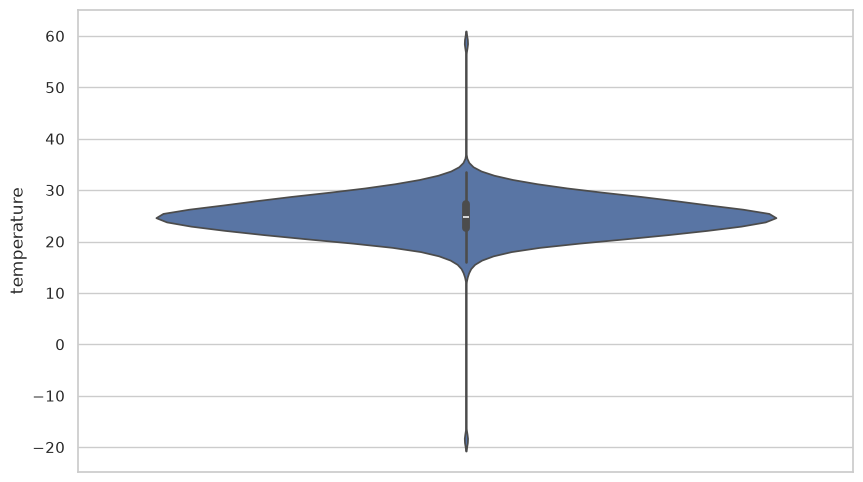

In [49]:
sns.violinplot(data=df, y="temperature")
plt.show()

Les températures restent comprises globalement entre 10 et 40 °C, avec un renflement plus large (donc une concentration plus forte de données) entre 20 et 30 °C, ce qui confirme le pic déjà observé avec l'histogramme et le KDE.

###  2) Afficher la distribution des températures par bâtiment

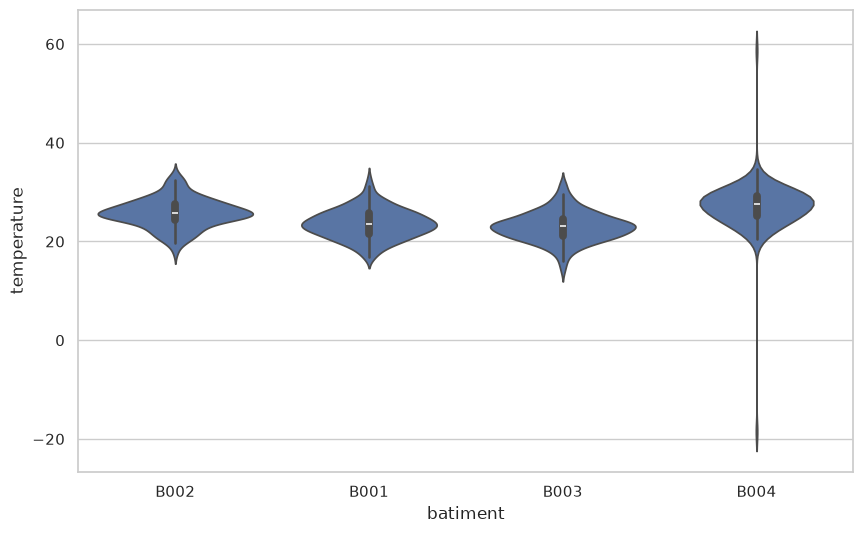

In [50]:
sns.violinplot(data=df, x="batiment", y="temperature")
plt.show()

Les violons des 4 bâtiments ont une taille globalement similaire, ce qui confirme la dispersion homogène déjà vue avec le boxplot (B001, B002, B003). 

En revanche, le violon de B004 se distingue par une queue beaucoup plus longue et fine, qui s'étend bien au-delà des autres, au point de sortir de l'échelle d'affichage commune aux autres bâtiments. 

Ça illustre bien la présence des valeurs extrêmes déjà identifiées (-18,50 °C et 58,70 °C).

###  3) Quelles informations supplémentaires le violin plot permet-il de visualiser par rapport au box plot

Le boxplot résume la distribution avec seulement quelques repères statistiques (médiane, quartiles, moustaches, outliers isolés), mais il ne montre pas la forme réelle de la distribution. 

Deux distributions très différentes (par exemple une avec un seul pic, une autre avec deux pics) peuvent donner exactement le même boxplot.

Le violin plot, lui, ajoute la densité complète de la distribution (comme un KDE) de chaque côté du boxplot. 

**Ça permet de voir en plus :**

où se concentrent réellement les données (les renflements/bosses), pas juste les quartiles

si la distribution est unimodale ou multimodale (un seul pic ou plusieurs pics)

la forme précise de la traîne des valeurs extrêmes (comme la longue queue fine de B004), plutôt que de simples points isolés comme sur le boxplot

**En résumé :** le boxplot donne un résumé statistique compact, le violin plot ajoute la richesse visuelle de la forme de la distribution, un peu comme combiner boxplot + kdeplot en un seul graphique.

## Partie 5 – Comptage des catégories avec countplot()

### 1) Afficher le nombre de mesures par état

**Objectifs :** ici on compte des occurrences de variables catégorielles (état des capteurs, bâtiments). 

**countplot()** affiche une barre par catégorie, dont la hauteur = le nombre de lignes ayant cette valeur.

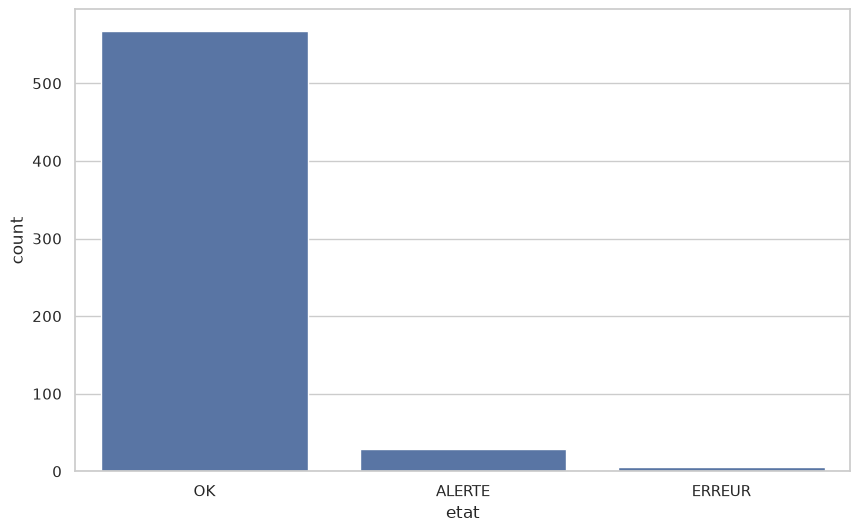

In [51]:
sns.countplot(data=df, x="etat")
plt.show()

**Explication :** x="etat" regroupe les lignes par valeur de la colonne etat (OK, ALERTE, ERREUR) et compte combien de fois chaque valeur apparaît. 

Contrairement à histplot(), il n'y a pas de calcul de densité ou de bins ici — c'est un simple comptage.

### 2) Afficher le nombre de mesures par bâtiment

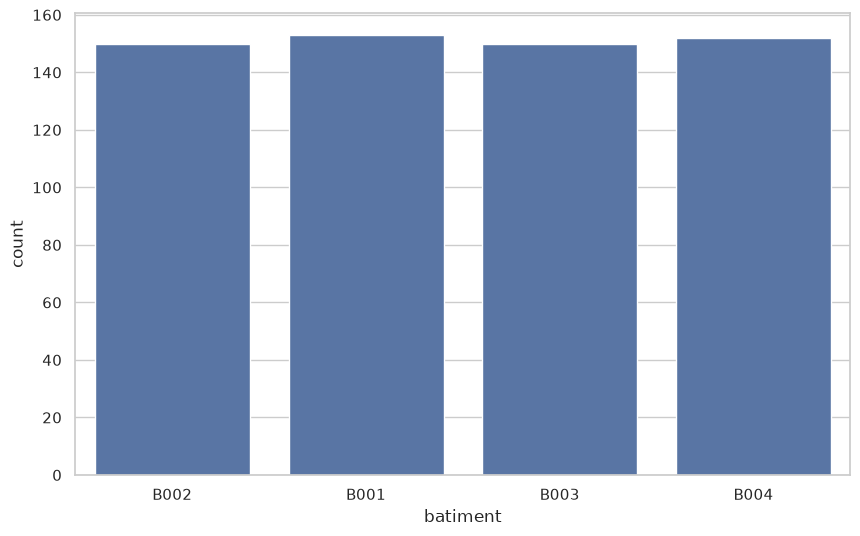

In [52]:
sns.countplot(data=df , x="batiment")
plt.show()

### 3) Afficher les états des capteurs par bâtiment pour identifier  

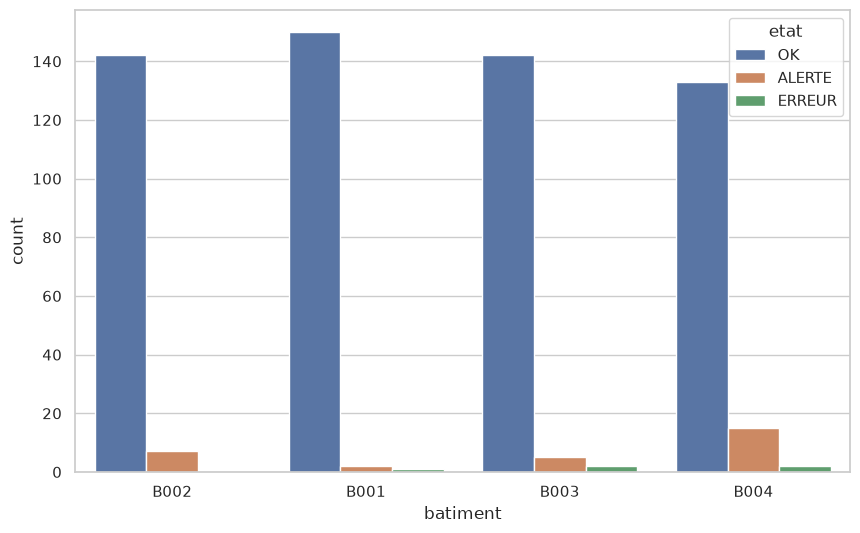

In [53]:
sns.countplot(data=df, x="batiment", hue="etat")
plt.show()

#### a) le bâtiment ayant le plus de mesures en état OK ;

B001 a le plus de mesures en état OK (150), suivi de près par B002 et B003 (142 chacun), tandis que B004 en a le moins (133).

#### b) celui ayant le plus de mesures en ALERTE ;

B004 a nettement le plus de mesures en ALERTE (15, contre 2 à 7 pour les autres bâtiments).

#### c) celui ayant le plus de mesures en ERREUR.

In [54]:
df.groupby(["batiment", "etat"]).size().unstack(fill_value=0)

etat,ALERTE,ERREUR,OK
batiment,,,
B001,2,1,150
B002,7,0,142
B003,5,2,142
B004,15,2,133


Pour les ERREUR, B003 et B004 sont à égalité (2 chacun), B001 en a 1, et B002 n'en a aucun.

## Partie 6 – Relation entre deux variables avec scatterplot()

**Objectif :** Jusqu'ici on étudiait une seule variable à la fois (distribution) ou une variable numérique face à une catégorie (bâtiment). 

Ici, on regarde la relation entre deux variables numériques : température et consommation. 

Chaque point du graphique = une mesure, positionnée selon sa température (x) et sa consommation (y).

 ### 1) Etudier graphiquement la relation entre température et consommation

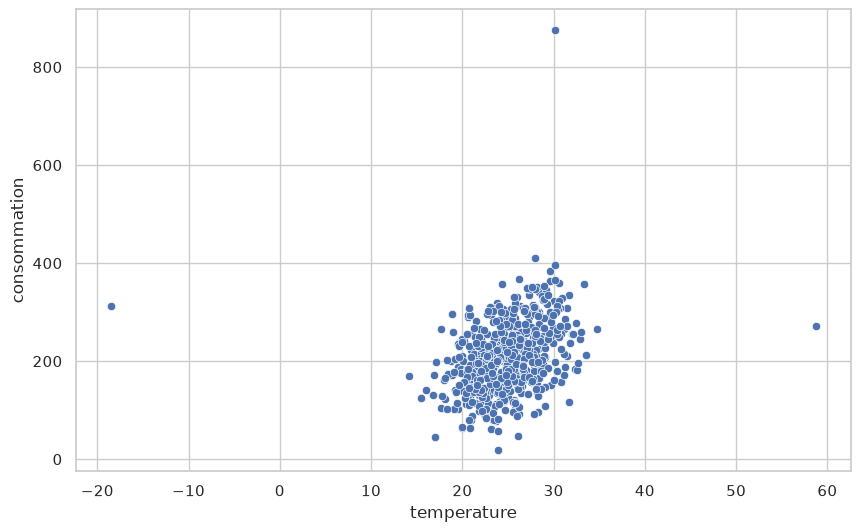

In [55]:
sns.scatterplot(data=df, x="temperature", y="consommation")
plt.show()

**Explication :** x="temperature" et y="consommation" — chaque point représente une mesure unique. Ça permet de voir visuellement si les deux variables évoluent ensemble (tendance croissante/décroissante) ou n'ont pas de lien apparent (nuage de points dispersé sans forme).

### 2) Etudier graphiquement la relation entre température et consommation par bâtiment

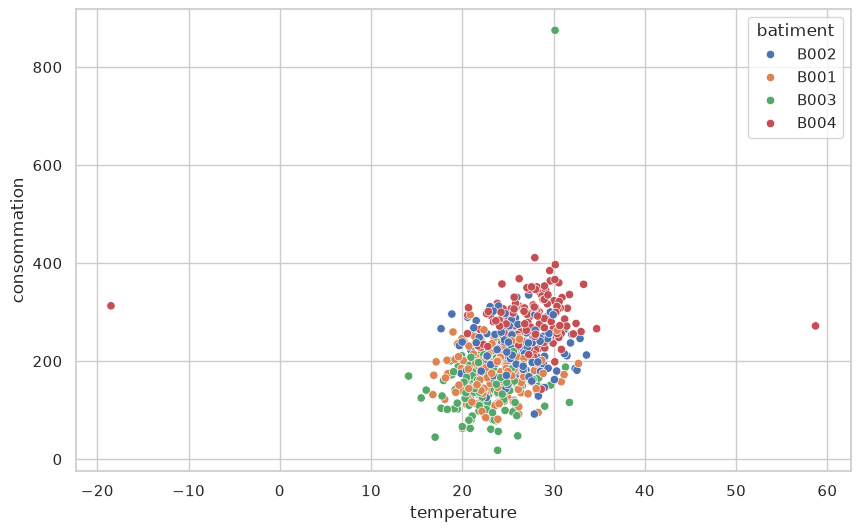

In [56]:
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment")
plt.show()

**Explication :** hue="batiment" colore les points selon le bâtiment, ce qui permet de voir si la relation température/consommation est différente d'un bâtiment à l'autre (une couleur = un bâtiment).

### 3) Modifier la taille des points 

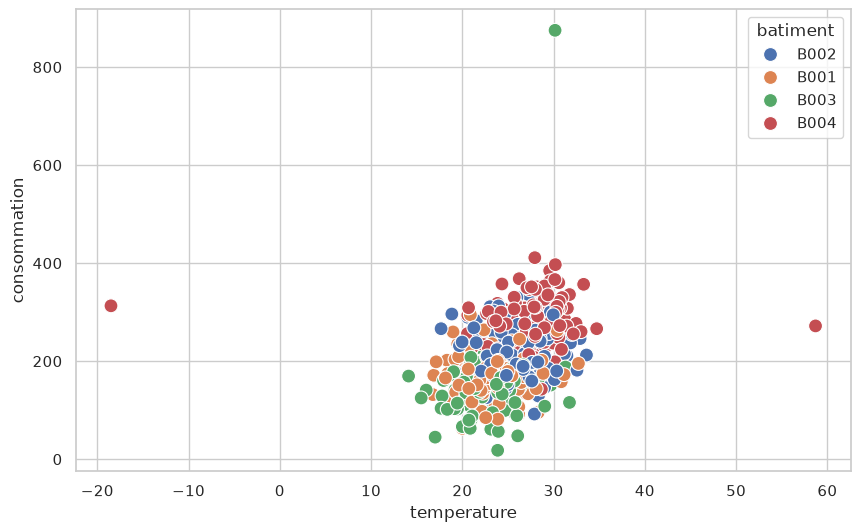

In [57]:
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment", s=100)
plt.show()

**Explication :** s (size) contrôle la taille des points (en points², une unité matplotlib). Par défaut c'est assez petit ; l'augmenter (ex: s=100) rend chaque point plus visible, utile surtout si le nuage de points est peu dense ou pour une meilleure lisibilité en présentation.